In [122]:

import pandas as pd
import seaborn
import seaborn as sns
import xgboost
from catboost import CatBoostRegressor

from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures,PowerTransformer
from sklearn.model_selection import train_test_split,cross_val_score,KFold
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
import lightgbm
from sklearn.linear_model import LinearRegression,Ridge,Lasso
import optuna
from sklearn.model_selection import cross_val_score,cross_validate,cross_val_predict
from sklearn.ensemble import IsolationForest
from statsmodels.api import OLS
import  statsmodels.api as sm


In [ ]:
def load_data():
    X = pd.read_csv("StudentPerformanceFactors.csv")
    pow = PowerTransformer(method='box-cox')
    X["Exam_Score"]=pow.fit_transform(pd.DataFrame(X["Exam_Score"]))
    X.drop(columns=["Gender","Sleep_Hours","School_Type"],inplace=True)
    X=X.dropna().reset_index(drop=True)
    #X["outlier"] = np.where(X["Exam_Score"]>78,1,0)
    #X = X[X["outlier"]!=1].reset_index()
    pow = PowerTransformer()

    #
    #X = X[X["Exam_Score"] < 78]
    y = X["Exam_Score"]

    X.drop(columns=["Exam_Score"], inplace=True)


    return X,y
X,y = load_data()


c:\Users\joona\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Exam_Score', ylabel='Count'>

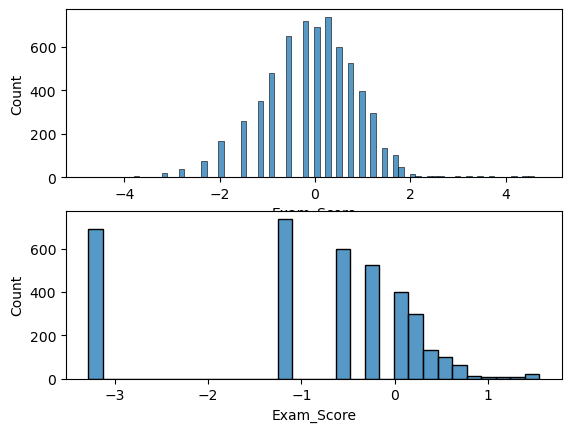

In [125]:
X,y=load_data()

fig,axs = plt.subplots(2,1)
sns.histplot(y,ax=axs[0])
sns.histplot(np.log(y),ax=axs[1])




## ALKAA

R2 Score: 0.8630905095104946
R2 OLS: 0.8630905095104946


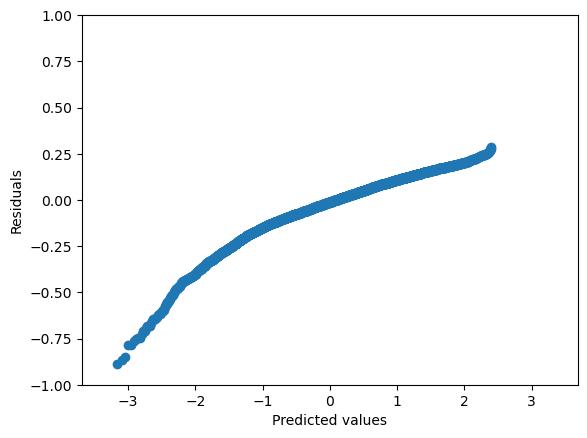

In [162]:
import shap
X,y=load_data()
#y = np.log(y)


categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False,drop="first")
encoded = encoder.fit_transform(X[categorical_columns])
X.drop(columns=categorical_columns,inplace=True)
encoded_names = encoder.get_feature_names_out()
X = pd.concat(
    [X, pd.DataFrame(encoded, columns=encoded_names, index=X.index)],
    axis=1
)
scaler = StandardScaler()
X[numeric] = scaler.fit_transform(X[numeric])

X.columns = X.columns.astype(str)
X,X_test,y,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

lm = LinearRegression()
lm.fit(X,y)
preds = lm.predict(X_test)
r2 = r2_score(y_test,preds)
print(f'R2 Score: {r2}')
coefs = pd.DataFrame({"feature": X.columns, "coef": lm.coef_})

#explainer = shap.LinearExplainer(lm, X)
#shap_values = explainer(X)
#shap.summary_plot(shap_values)

coefs.sort_values(by="coef",ascending=False,inplace=True)
coefs
X_train = sm.add_constant(X)
X_test = sm.add_constant(X_test)
ols =OLS(y,X_train)
ols_model = ols.fit()
preds_ols = ols_model.predict(X_test)
r2_ols =r2_score(y_test,preds_ols)
print(f'R2 OLS: {r2_ols}')
ols_model.summary()

res = ols_model.resid # residuals
#Q-Q kuvaaja
sm.qqplot(res)
pd.DataFrame(coefs)
resid_ols = y_test - preds_ols

#sns.scatterplot(x=preds_ols,y=resid_ols)
#plt.xlim((-1,1))
plt.ylim((-1,1))
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()

array([[ 1.65377603],
       [-0.24673113],
       [ 0.80506073],
       ...,
       [-1.20744611],
       [ 0.03846194],
       [ 1.65377603]])

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

nums = X_train.select_dtypes(include=[int,float]).columns.tolist()
categories = X_train.select_dtypes(include="object").columns.tolist()
scaler = StandardScaler()
encoder=OneHotEncoder(sparse_output=False,drop="first")


scaler.fit(X_train[nums])
X_train[nums] = scaler.transform(X_train[nums])
X_test[nums] = scaler.transform(X_test[nums])

encoder.fit(X_train[categories])
train_encoded = encoder.transform(X_train[categories])
test_encoded = encoder.transform(X_test[categories])
X_train.drop(columns=categories,inplace=True)
X_test.drop(columns=categories,inplace=True)

X_train = np.hstack([train_encoded,X_train])
X_test = np.hstack([test_encoded,X_test])

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
ols =OLS(y_train,X_train)
ols_model = ols.fit()
preds = ols_model.predict(X_test)
r2 =r2_score(y_test,preds)
print(r2)
ols_model.summary()

0.7531818374182273


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Exam_Score   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     532.2
Date:                Mon, 01 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:49:59   Log-Likelihood:                 7991.0
No. Observations:                3571   AIC:                        -1.593e+04
Df Residuals:                    3546   BIC:                        -1.578e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2064      0.000   9701.995      0.000       4.206       4.207
x1             0.0265      0.000     60.964      0.000       0.026       0.027
x2             0.0343      0.000     78.813      0.000       0.033       0.035
x3             0.0106      0.000     24.239      0.000       0.010       0.011
x4             0.0090      0.000     20.663      0.000       0.008       0.010
x5             0.0032      0.000      7.409      0.000       0.002       0.004
x6            -0.0121      0.001    -23.914      0.000      -0.013      -0.011
x7            -0.0078      0.001    -15.376      0.000      -0.009      -0.007
x8            -0.0123      0.001    -24.449      0.000      -0.013      -0.011
x9            -0.0075      0.001    -14.934      0.000      -0.009      -0.007
x10            0.0041      0.000      9.517      0.000       0.003       0.005
x11           -0.0070      0.001    -12.194      0.000      -0.008      -0.006
x12           -0.0042      0.001     -7.262      0.000      -0.005      -0.003
x13            0.0035      0.000      8.025      0.000       0.003       0.004
x14           -0.0082      0.001    -13.847      0.000      -0.009      -0.007
x15           -0.0041      0.001     -6.933      0.000      -0.005      -0.003
x16           -0.0041      0.000     -8.555      0.000      -0.005      -0.003
x17           -0.0034      0.000     -7.107      0.000      -0.004      -0.002
x18            0.0041      0.001      7.196      0.000       0.003       0.005
x19            0.0073      0.001     12.770      0.000       0.006       0.008
x20           -0.0043      0.000     -9.892      0.000      -0.005      -0.003
x21           -0.0037      0.000     -7.379      0.000      -0.005      -0.003
x22            0.0028      0.000      5.603      0.000       0.002       0.004
x23            0.0026      0.001      3.474      0.001       0.001       0.004
x24            0.0064      0.001      8.667      0.000       0.005       0.008
==============================================================================
Omnibus:                     5995.288   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3043869.534
Skew:                          11.573   Prob(JB):                         0.00
Kurtosis:                     144.144   Cond. No.                         3.10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [159]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
import numpy as np
X,y = load_data()
#y = np.log(y)
categorical_columns = X.select_dtypes(include=object).columns.tolist()
numerical_columns = X.select_dtypes(exclude=object).columns.tolist()
transformer = ColumnTransformer([
    ("onehot",OneHotEncoder(sparse_output=False,drop="first"),categorical_columns),
     ("scaler",StandardScaler(),numerical_columns)
])
pipeline = Pipeline([
    ("preprocess",transformer),
    ("model",LinearRegression())
])

print(f'Linear CV: {np.mean(cross_val_score(pipeline,X,y))} ')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
scores_ols=[]
scores_train = []
for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y[train_idx].copy(), y[val_idx].copy()

    onehot = OneHotEncoder(sparse_output=False,drop="first")
    scaler =StandardScaler()

    X_train_encoded = onehot.fit_transform(X_train[categorical_columns])
    X_val_encoded = onehot.transform(X_val[categorical_columns])
    encoded_names = onehot.get_feature_names_out()


    X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
    X_val[numerical_columns] = scaler.transform(X_val[numerical_columns])
    X_train  = pd.concat([X_train[numerical_columns],pd.DataFrame(X_train_encoded,columns=encoded_names,index = X_train.index)],axis=1)
    X_val = pd.concat([X_val[numerical_columns],pd.DataFrame(X_val_encoded,columns=encoded_names,index = X_val.index)],axis=1)


    model = XGBRegressor(random_state=42,early_stopping_rounds=50,learning_rate=0.2,max_depth=3,n_estimators=1000)
    model.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=False)
    preds = model.predict(X_val)
    preds_tr = model.predict(X_train)
    r2 = r2_score(y_val,preds)

    X_train = sm.add_constant(X_train)
    X_val = sm.add_constant(X_val)
    ols =OLS(y_train,X_train)
    ols_model = ols.fit()
    preds = ols_model.predict(X_val)
    r2_ols =r2_score(y_val,preds)

    scores_ols.append(r2_ols)

    scores.append(r2)
print(f'SCORE OLS val {np.mean(scores_ols)}')
print(f'SCORE XGB val {np.mean(scores)}')



Linear CV: 0.8566566391711644 
SCORE OLS val 0.8573763802088227
SCORE XGB val 0.8480863538214012


## LOPPUU

In [ ]:
def test_fitting(X_train, y_train, X_val, y_val, model):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_score = r2_score(y_train, y_train_pred)
    val_score = r2_score(y_val, y_val_pred)

    score_gap = train_score - val_score

    # For R²: higher is better
    if train_score > 0.9 and val_score < 0.7 and score_gap > 0.15:
        diagnosis = "overfitting"
    elif train_score < 0.6 and val_score < 0.6:
        diagnosis = "underfitting"
    elif abs(score_gap) <= 0.05 and val_score >= 0.7:
        diagnosis = "good_fit"
    else:
        diagnosis = "borderline"
    return diagnosis, train_score, val_score, score_gap
X,y = load_data()
cat =X.select_dtypes(include=object).columns.tolist()
X[cat] = X[cat].astype("category")
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)
model = XGBRegressor(random_state=42,learning_rate=0.2,max_depth=3,n_estimators=200,enable_categorical=True)


model.fit(X_train,y_train)
test_fitting(X_train,y_train, X_val, y_val, model)

In [ ]:
#students = pd.read_csv("StudentPerformanceFactors.csv")
students,exam_score = load_data()
students["Exam_Score"] = exam_score
fig,axs = plt.subplots(ncols=3,nrows=2,figsize=(15,10))
sns.scatterplot(data=students,x="Hours_Studied",y="Exam_Score",ax=axs[0,0],hue="outlier")
sns.scatterplot(data=students,x="Attendance",y="Exam_Score",ax=axs[0,1],hue="outlier")
sns.scatterplot(data=students,x="Previous_Scores",y="Exam_Score",ax=axs[1,0],hue="outlier")
sns.boxplot(data=students,x="Physical_Activity",y="Exam_Score",ax=axs[1,1],hue="outlier")
sns.boxplot(data=students,x="Tutoring_Sessions",y="Exam_Score",ax=axs[1,2],hue="outlier")
sns.boxplot(data=students,x="Sleep_Hours",y="Exam_Score",ax=axs[0,2],hue="outlier")

In [ ]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include="object").columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model = XGBRegressor(n_estimators=1500,learning_rate=0.02,enable_categorical=True,reg_lambda=10,random_state=42,early_stopping_rounds = 50)
model.fit(X_train,y_train,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model.predict(X_test)

resid = preds-y_test
r2 = r2_score(y_test,preds)


print(f'R2 full {r2} ')

resid = y_test-preds
xgboost.plot_importance(model)
#sns.scatterplot(x=preds,y=y_test,hue  =resid)

## CAT

In [ ]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model_cat =CatBoostRegressor(use_best_model=True,early_stopping_rounds=50)
model_cat.fit(X_train,y_train,cat_features=categorical_columns,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model_cat.predict(X_test)
r2_test=r2_score(y_test,preds)
preds_full =model_cat.predict(X)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


## LGBM

In [ ]:

X,y =  load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
params = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
model = lightgbm.LGBMRegressor(**params,random_state=42,early_stopping_rounds = 50,n_estimators=5000)
model.fit(X_train,y_train,categorical_feature=categorical_columns,eval_set=[(X_validation,y_validation)])
preds = model.predict(X_test)
preds_full = model.predict(X)
r2 = r2_score(y_test,preds)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


In [ ]:
X,y =  load_data()
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X[categorical_columns] = X[categorical_columns].astype("category")

paramsXGB = {
        "n_estimators":3000,
        "max_depth":3,
        "gamma":1.4,
        "subsample":0.8,
    "learning_rate":0.01
    }
params_lgbm = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
X,X_val,y,y_val = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)
xgb = XGBRegressor(**paramsXGB,random_state=42,enable_categorical=True,early_stopping_rounds=50)
cat = CatBoostRegressor(random_state=42,use_best_model=True,early_stopping_rounds=50)
lgbm = lightgbm.LGBMRegressor(**params_lgbm,random_state=42,use_best_model=True,early_stopping_rounds=50,verbosity=-1)
print(np.mean(cross_validate(cat,X,y,params={"cat_features": categorical_columns,"eval_set":[(X_val,y_val)],"verbose":500})["test_score"]))
print(np.mean(cross_validate(xgb,X,y,params={"eval_set":[(X_val,y_val)],"verbose":0})["test_score"]))
print(np.mean(cross_validate(lgbm,X,y,params={"eval_set":[(X_val,y_val)]})["test_score"]))